In [9]:
import numpy as np
import re
from collections import Counter
from sklearn.neighbors import KDTree
import compress_fasttext
import matplotlib.pyplot as plt
from ruwordnet import RuWordNet
import xmltodict
import fasttext


In [10]:
# Инициализация WordNet и FastText
wn = RuWordNet()
ft = fasttext.load_model('/Users/juliak/PycharmProjects/MSP/WSD/cc.ru.300.bin')

In [12]:
# Вспомогательные функции

def vectorize(text):
    vecs = [ft[w] for w in text.lower().split() if w in ft and len(w)>=3]
    if not vecs:
        return np.zeros(ft.vector_size)
    vec = np.mean(vecs, axis=0)
    return vec / np.linalg.norm(vec)

In [13]:
# Функция для разрешения неоднозначности

def disambiguate(word: str, context: str, topn: int = 3) -> list:
    """
    Для заданного слова и его контекста возвращает список (score, synset)
    наибольших по сходству соусловно-векторным голосованием.
    """
    # получаем все возможные смысла
    senses = wn.get_senses(word)
    # строим эмбеддинг контекста (без самого слова)
    ctx = ' '.join([t for t in re.findall(r"\w+", context.lower()) if t != word.lower()])
    cvec = vectorize(ctx)

    # собираем эмбеддинги кандидатов: леммы + их гипонимы для расширения
    cand_embs = []
    cand_ids = []
    for s in senses:
        tokens = s.name.lower().split()  # слова названия смысла
        emb = vectorize(' '.join(tokens))
        cand_embs.append(emb)
        cand_ids.append(s.synset.id)
        # добавим ко-гипонимы для усиления семантики
        for hypo in s.synset.hypernyms:
            for hs in hypo.hyponyms:
                emb2 = vectorize(hs.title)
                cand_embs.append(emb2)
                cand_ids.append(hs.id)

    # kd-tree для поиска соседних эмбеддингов
    tree = KDTree(np.stack(cand_embs))
    dists, idxs = tree.query(cvec.reshape(1,-1), k=min(topn, len(cand_embs)))

    # голосуем за гипернимы каждого ближайшего смысла
    votes = Counter()
    for dist, idx in zip(dists[0], idxs[0]):
        sid = cand_ids[idx]
        for hyper in wn[sid].hypernyms:
            votes[hyper.id] += np.exp(-dist)

    # возвращаем топ-N гипернимов как результаты
    results = []
    for synid, score in votes.most_common(topn):
        results.append((score, wn[synid].title))
    return results

Disambiguate in crafts context: [(0.6652759839881992, 'ЗАПОР, ЗАПОРНОЕ УСТРОЙСТВО'), (0.33438704114317686, 'ДЕТАЛЬ УСТРОЙСТВА')]
Disambiguate in castle context : [(0.7144890228241992, 'ДВОРЕЦ'), (0.7144890228241992, 'КРЕПОСТЬ (ОБОРОНИТЕЛЬНОЕ СООРУЖЕНИЕ)')]


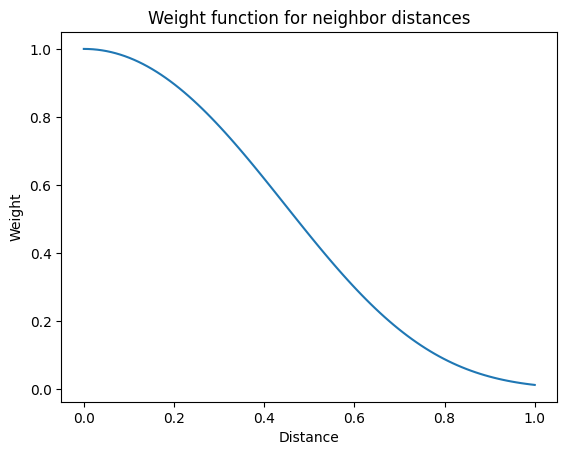

In [15]:
# Пример использования

if __name__ == '__main__':
    word = 'замок'
    ctx1 = 'Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок - бороздку, называемую зигом, которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'
    ctx2 = 'Издали видны королевский замок Вавель и кафедральный собор.'
    print('Disambiguate in crafts context:', disambiguate(word, ctx1, topn=2))
    print('Disambiguate in castle context :', disambiguate(word, ctx2, topn=2))

    # Визуализация функции расстояния-голоса
    xs = np.linspace(0,1,100)
    ys = np.exp(-xs**3) * np.maximum(0,1-xs**2/2)**5
    plt.plot(xs, ys)
    plt.title('Weight function for neighbor distances')
    plt.xlabel('Distance')
    plt.ylabel('Weight')
    plt.show()